Evaluate

In [1]:
def evaluate_model(model, dataset_loader, scale_data=True, test_size=0.2, random_state=42):
    # Load dataset
    dataset = dataset_loader()
    X, y = dataset.data, dataset.target
    print(f"\n📊 Evaluating on dataset: {dataset_loader.__name__} - {X.shape[0]} samples, {X.shape[1]} features")

    if scale_data:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Use the instance directly
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    print("✅ Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))
    #print("📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Evaluating Function with plots

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model_with_plots(model, dataset_loader, scale_data=True, test_size=0.2, random_state=42):
    # Load dataset
    dataset = dataset_loader()
    X, y = dataset.data, dataset.target
    print(f"\n📊 Evaluating on dataset: {dataset_loader.__name__} - {X.shape[0]} samples, {X.shape[1]} features")

    # Optional scaling
    if scale_data:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    # Train/test split
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Train the model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

    if hasattr(model, 'predict_proba') or set(np.unique(y)).issubset({0, 1}):
        # Classification
        print("✅ Accuracy:", round(accuracy_score(y_test, y_pred), 4))
        print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))
        
        # Confusion matrix plot
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("🔷 Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        # 2D decision boundary if applicable
        if X.shape[1] == 2:
            plot_decision_boundary(model, X_test, y_test)

    else:
        # Regression
        print("✅ R² Score:", round(r2_score(y_test, y_pred), 4))
        print("📉 RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

        # Regression scatter
        plt.figure(figsize=(6, 4))
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title("🔧 Actual vs Predicted")
        plt.show()

        # If 1 feature, plot regression line
        if X.shape[1] == 1:
            plt.figure(figsize=(6, 4))
            plt.scatter(X_test, y_test, color='blue', label='Actual')
            plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression line')
            plt.xlabel("Feature")
            plt.ylabel("Target")
            plt.title("📈 Linear Regression Line")
            plt.legend()
            plt.show()

def plot_decision_boundary(model, X, y):
    # Only supports 2D
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='coolwarm', edgecolor='k')
    plt.title("🧭 Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


KNN


📊 Evaluating on dataset: load_iris - 150 samples, 4 features
✅ R² Score: 1.0
📉 RMSE: 0.0


d:\Softwares\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


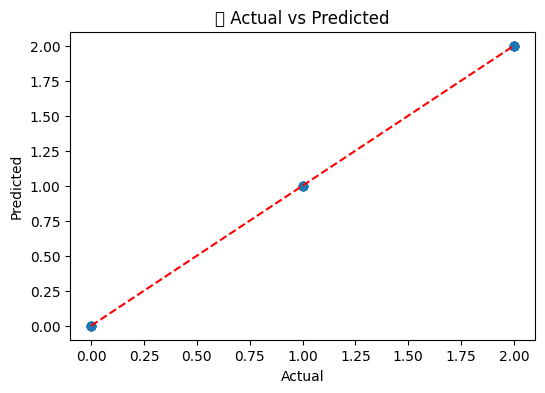

In [7]:
from KNN import KNN
from sklearn.datasets import load_iris
KNN_model = KNN(k=3)
evaluate_model_with_plots(KNN_model, load_iris)

Linear Regression


📊 Evaluating on dataset: load_diabetes - 442 samples, 10 features
✅ R² Score: 0.4554
📉 RMSE: 53.7136


d:\Softwares\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


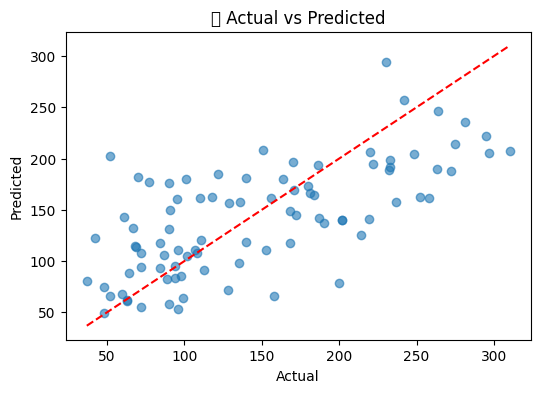

In [8]:
import numpy as np
from sklearn.datasets import load_diabetes
from Linear_Regression import Linear_Regression
lr = Linear_Regression(lr=0.01)
evaluate_model_with_plots(lr, load_diabetes, scale_data=True)

Logistic Regression


📊 Evaluating on dataset: load_breast_cancer - 569 samples, 30 features
✅ Accuracy: 0.9825

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



d:\Softwares\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


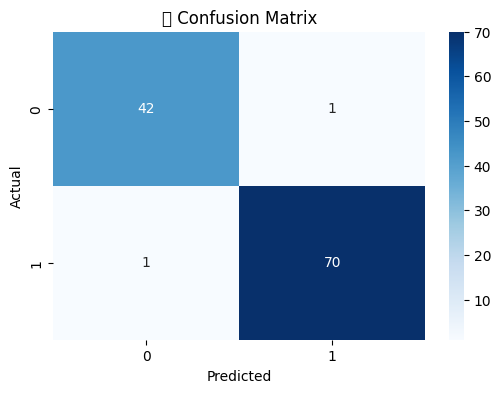

In [9]:
from sklearn.datasets import load_breast_cancer
from Logistic_Regression import Logistic_Regression

lgr = Logistic_Regression()
evaluate_model_with_plots(lgr, load_breast_cancer, scale_data=True)

Naive Bayes

d:\Softwares\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



📊 Evaluating on dataset: load_iris - 150 samples, 4 features
✅ R² Score: 1.0
📉 RMSE: 0.0


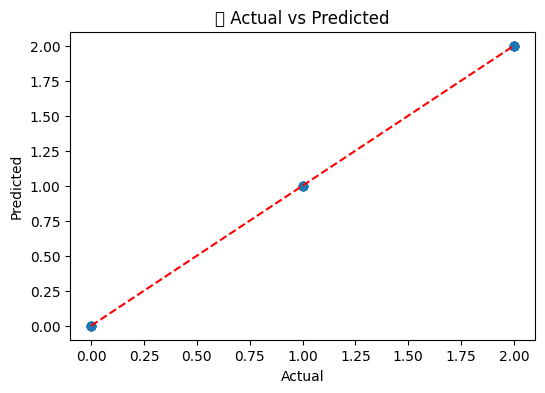

In [10]:
from sklearn.datasets import load_iris
from NaiveBayes import NaiveBayes

NB = NaiveBayes()
evaluate_model_with_plots(NB, load_iris, scale_data=True)

SVM

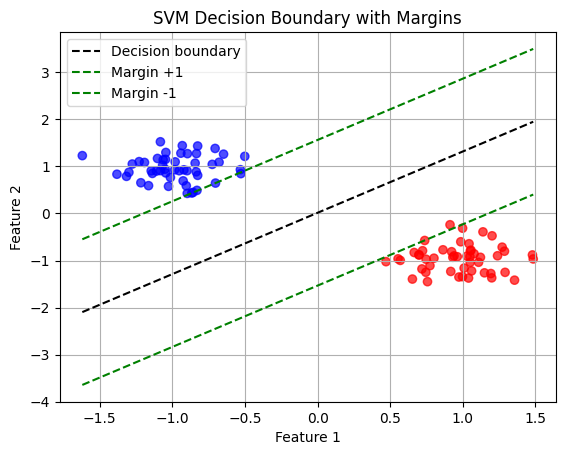

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from SVM import BinarySVM

# Generate simple dataset
X, y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train the BinarySVM
svm = BinarySVM()
svm.fit(X, y)

# Plotting decision boundary and margins
def plot_decision_boundary(X, y, svm):
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]

    fig, ax = plt.subplots()
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)

    x0 = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 100)
    x1 = get_hyperplane_value(x0, svm.w, svm.b, 0)
    x1_margin_pos = get_hyperplane_value(x0, svm.w, svm.b, 1)
    x1_margin_neg = get_hyperplane_value(x0, svm.w, svm.b, -1)

    ax.plot(x0, x1, 'k--', label='Decision boundary')
    ax.plot(x0, x1_margin_pos, 'g--', label='Margin +1')
    ax.plot(x0, x1_margin_neg, 'g--', label='Margin -1')
    ax.legend()
    plt.title("SVM Decision Boundary with Margins")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

plot_decision_boundary(X, y, svm)


📊 Evaluating on dataset: load_breast_cancer - 569 samples, 30 features
✅ Accuracy: 0.9561

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94        43
           1       0.99      0.94      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



d:\Softwares\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128311 (\N{LARGE BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


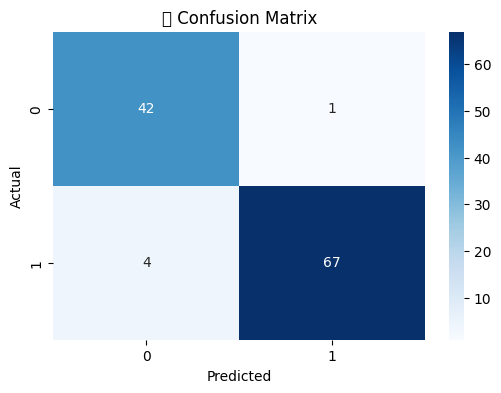

In [2]:
from sklearn.datasets import load_breast_cancer
from SVM import SVM

svm = SVM()

evaluate_model_with_plots(svm, load_breast_cancer, scale_data=True)

In [ ]:
from sklearn.datasets import load_wine
from Decision_Tree import DecisionTree

decisionTree_model = DecisionTree()
evaluate_model_with_plots(decisionTree_model, load_wine, scale_data=True)



📊 Evaluating on dataset: load_wine - 178 samples, 13 features


TypeError: DecisionTree._traverse_tree() missing 1 required positional argument: 'node'

In [13]:
# load_diabetes()- linear regression, ridge, lasso,
# load_breast_cancer()- logistic regression, SVM, decision tree, random forest
# load_wine()- logistic regression, SVM, decision tree, random forest
# load_digits()- KMeans, PCA, t-SNE